# AAMD — Plantilla de Examen
**Nombre: Marcos Pérez Martínez**

Plantilla lista para examen. Cambia la **CELDA CONFIG** (fichero, target, columnas, random_state, test_size) y ejecuta de arriba a abajo (`Kernel > Restart & Run All`).

El MLP/MLPRelu se **importan** del módulo `practica5_mlp.py` (debe estar en la misma carpeta / zip). No se duplica código de la práctica.

Orden: Config → Imports (incl. módulo MLP) → Carga → Limpieza → Encoding → Split/Escalado → Scatter → MLP propio → sklearn (MLPClassifier/KNN/RandomForest/Tree) → Comparación → MLPRelu → (binario).

In [ ]:
# ===== CONFIG =====
FILE        = "Customer.csv"     # nombre del CSV (ruta relativa al notebook)
TARGET      = "Segmentation"            # columna objetivo
COLS_DROP   = ["ID"]           # columnas a eliminar
RANDOM_STATE = 13                
TEST_SIZE    = 0.20              

In [38]:
# ===== IMPORTS =====
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

from practica5_mlp import MLP, MLPRelu, to_onehot

def evaluar(nombre, modelo, Xtr, ytr, Xte, yte, plot=True):
    modelo.fit(Xtr, ytr)
    atr = accuracy_score(ytr, modelo.predict(Xtr))
    ate = accuracy_score(yte, modelo.predict(Xte))
    print(f"{nombre}: train={atr:.3f}  test={ate:.3f}")
    if plot:
        ConfusionMatrixDisplay(confusion_matrix(yte, modelo.predict(Xte))).plot()
        plt.title(nombre); plt.show()
    return ate

In [39]:
# ===== CARGA + EXPLORACION =====
df = pd.read_csv(FILE)
print(df.shape)
display(df.head())
df.info()
print(df.isna().sum())
print(df[TARGET].value_counts())

(10695, 11)


,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10695 entries, 0 to 10694
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               10695 non-null  int64  
 1   Gender           10695 non-null  object 
 2   Ever_Married     10505 non-null  object 
 3   Age              10695 non-null  int64  
 4   Graduated        10593 non-null  object 
 5   Profession       10533 non-null  object 
 6   Work_Experience  9597 non-null   float64
 7   Spending_Score   10695 non-null  object 
 8   Family_Size      10247 non-null  float64
 9   Var_1            10587 non-null  object 
 10  Segmentation     8068 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 919.2+ KB
ID                    0
Gender                0
Ever_Married        190
Age                   0
Graduated           102
Profession          162
Work_Experience    1098
Spending_Score        0
Family_Size         448
Var_1        

In [42]:
# ===== LIMPIEZA + IMPUTACION =====
for c in COLS_DROP:
    if c in df.columns: df = df.drop(columns=[c])
df = df.dropna(subset=[TARGET]) # eliminamos filas con nulos en la columna objetivo

num_cols = df.select_dtypes(include=np.number).columns.drop(TARGET, errors="ignore")
cat_cols = df.select_dtypes(exclude=np.number).columns.drop(TARGET, errors="ignore")
for c in num_cols: df[c] = df[c].fillna(df[c].median())
for c in cat_cols: df[c] = df[c].fillna(df[c].mode()[0])
print("Nulos restantes:", int(df.isna().sum().sum()))
df.info()

Nulos restantes: 0
<class 'pandas.core.frame.DataFrame'>
Index: 8068 entries, 0 to 8067
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Gender           8068 non-null   object 
 1   Ever_Married     8068 non-null   object 
 2   Age              8068 non-null   int64  
 3   Graduated        8068 non-null   object 
 4   Profession       8068 non-null   object 
 5   Work_Experience  8068 non-null   float64
 6   Spending_Score   8068 non-null   object 
 7   Family_Size      8068 non-null   float64
 8   Var_1            8068 non-null   object 
 9   Segmentation     8068 non-null   object 
dtypes: float64(2), int64(1), object(7)
memory usage: 693.3+ KB


Se limpian celdas sin valor para el aprendizaje. Imputo numéricas con **mediana** y categóricas con **moda**, y aplico One-Hot a categóricas para que cualquier modelo las acepte.

In [43]:
# ===== ENCODING =====
X = pd.get_dummies(df.drop(columns=[TARGET]), drop_first=False).astype(float)
le = LabelEncoder()
y = le.fit_transform(df[TARGET])
n_clases = len(le.classes_)
print("features:", X.shape[1], "| clases:", n_clases, le.classes_)

features: 28 | clases: 4 ['A' 'B' 'C' 'D']


In [44]:
# ===== SPLIT + ESCALADO =====
X_train, X_test, y_train, y_test = train_test_split(
    X.to_numpy(), y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test  = sc.transform(X_test)
print(X_train.shape, X_test.shape)

(6454, 28) (1614, 28)


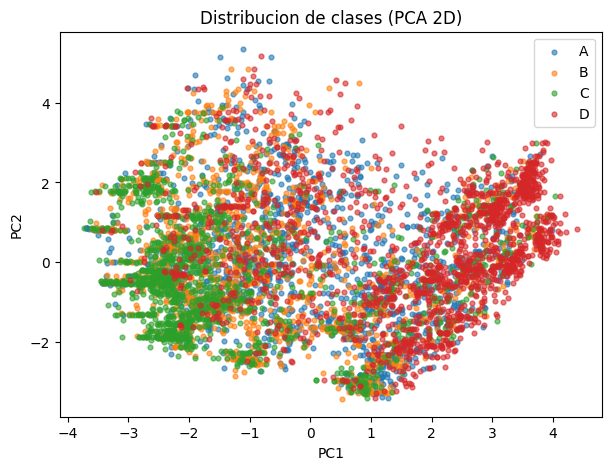

In [45]:
# ===== SCATTER DISTRIBUCION DE CLASES =====
X2 = PCA(n_components=2).fit_transform(X_train)
plt.figure(figsize=(7,5))
for c in range(n_clases):
    plt.scatter(X2[y_train==c,0], X2[y_train==c,1], s=12, alpha=.6, label=str(le.classes_[c]))
plt.legend(); plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title("Distribucion de clases (PCA 2D)"); plt.show()

  it 1: J=2.8240
  it 1001: J=1.8703
  it 2001: J=1.8454
  it 3000: J=1.7906
MLP [64,32,16] test: 0.524
  it 1: J=2.6125
  it 1001: J=1.8283
  it 2001: J=1.7890
  it 3000: J=1.7448
MLP final test: 0.54


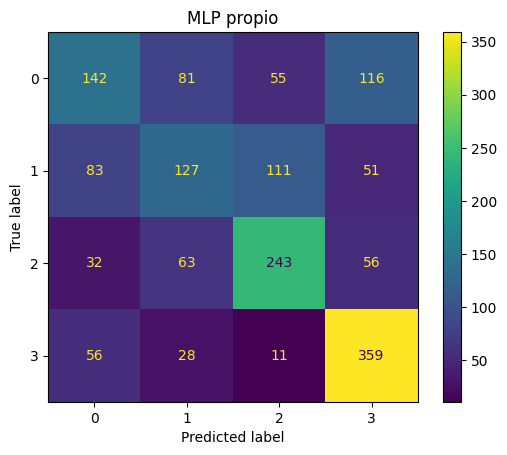

In [46]:
# ===== MLP PROPIO =====
y_train_oh = to_onehot(y_train, n_clases)

# Prueba EXIGIDA con >=3 capas ocultas
mlp3 = MLP(X_train.shape[1], [64,32,16], n_clases, seed=0)
mlp3.backpropagation(X_train, y_train_oh, alpha=1.0, lambda_=1.0, numIte=3000, verbose=1000)
acc3 = np.mean(mlp3.predict(mlp3.feedforward(X_test)[0][-1]) == y_test)
print("MLP [64,32,16] test:", round(acc3,3))

# Modelo final
mlp = MLP(X_train.shape[1], [64,32], n_clases, seed=0)
mlp.backpropagation(X_train, y_train_oh, alpha=1.0, lambda_=1.0, numIte=3000, verbose=1000)
y_pred_mlp = mlp.predict(mlp.feedforward(X_test)[0][-1])
acc_mlp = np.mean(y_pred_mlp == y_test); print("MLP final test:", round(acc_mlp,3))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_mlp)).plot(); plt.title("MLP propio"); plt.show()

**Modelo final MLP:** me quedo con `[64,32]` (similar o mejor que `[64,32,16]` con menos coste). Si no llega al minimo: subir `numIte`, ajustar `alpha` (0.3/1/3), bajar `lambda_`, o ampliar la red.

MLPClassifier: train=0.699  test=0.501


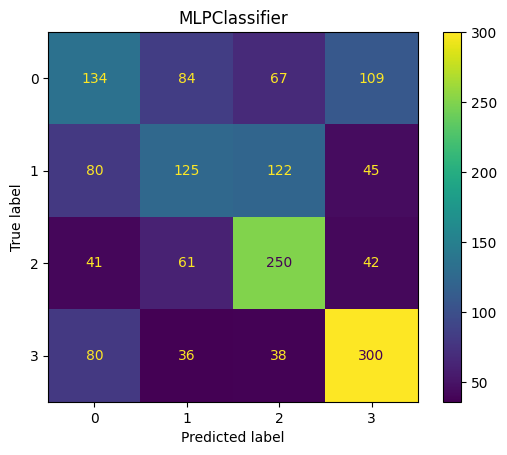

In [47]:
# ===== MLPClassifier =====
acc_sk = evaluar("MLPClassifier",
    MLPClassifier(hidden_layer_sizes=(64,32), activation="relu", max_iter=1000, random_state=0),
    X_train, y_train, X_test, y_test)

mejor k: 11
KNN(k=11): train=0.576  test=0.508


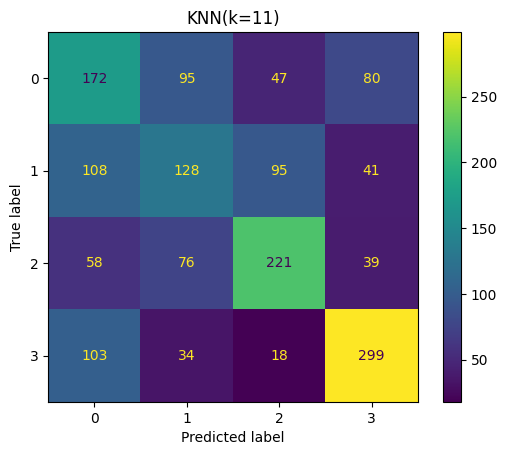

In [48]:
# ===== KNN — con busqueda de k =====
best_k, best = 5, 0
for k in [3,5,7,9,11,15]:
    a = accuracy_score(y_test, KNeighborsClassifier(k).fit(X_train,y_train).predict(X_test))
    if a > best: best_k, best = k, a
print("mejor k:", best_k)
acc_knn = evaluar(f"KNN(k={best_k})", KNeighborsClassifier(best_k), X_train, y_train, X_test, y_test)

RandomForest: train=0.955  test=0.496


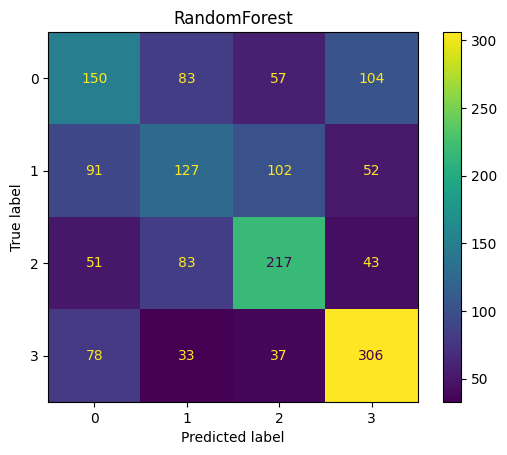

In [49]:
# ===== RandomForest =====
acc_rf = evaluar("RandomForest",
    RandomForestClassifier(n_estimators=200, random_state=42),
    X_train, y_train, X_test, y_test)

DecisionTree: train=0.955  test=0.441


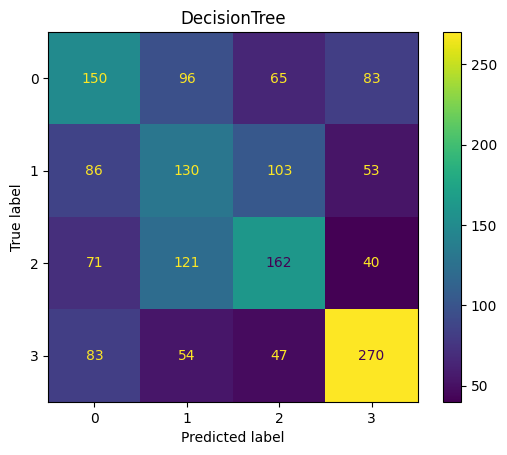

In [50]:
# ===== DecisionTree =====
acc_dt = evaluar("DecisionTree",
    DecisionTreeClassifier(random_state=42),
    X_train, y_train, X_test, y_test)

In [51]:
# ===== COMPARACION (Ej analisis) =====
res = {"MLP propio":acc_mlp, "MLPClassifier":acc_sk, "KNN":acc_knn,
       "RandomForest":acc_rf, "DecisionTree":acc_dt}
for k,v in sorted(res.items(), key=lambda x:-x[1]): print(f"{k:14s}: {v:.3f}")

MLP propio    : 0.540
KNN           : 0.508
MLPClassifier : 0.501
RandomForest  : 0.496
DecisionTree  : 0.441


**Análisis (Ej):** comparo train vs test de cada modelo (train≫test → overfitting; ambos bajos → underfitting). Elijo el de mayor accuracy de test (o mejor recall en la clase crítica si es deteccion médica). La matriz de confusión indica entre qué clases se confunde.

In [ ]:
# ===== MLPRelu: relu+softmax ~ sigmoid =====
m_sig = MLPRelu(X_train.shape[1], [64,32], n_clases, function="sigmoid", out_function="sigmoid")
m_sig.backpropagation(X_train, y_train_oh, alpha=1.0, lambda_=1.0, numIte=2000)
a_sig = np.mean(m_sig.predict(m_sig.feedforward(X_test)[0][-1]) == y_test)

m_rs = MLPRelu(X_train.shape[1], [64,32], n_clases, function="relu", out_function="softmax")
m_rs.backpropagation(X_train, y_train_oh, alpha=0.3, lambda_=1.0, numIte=2000)  # alpha menor con relu
a_rs = np.mean(m_rs.predict(m_rs.feedforward(X_test)[0][-1]) == y_test)
print("sigmoid:", round(a_sig,3), "| relu+softmax:", round(a_rs,3))

sigmoid: 0.533 | relu+softmax: 0.516


In [ ]:
# ===== (OPCIONAL) MLP BINARIO 1 neurona de salida (estilo 2024) =====
# y_bin = (df[TARGET] != "ClaseNegativa").astype(int).to_numpy()
# Xb_tr,Xb_te,yb_tr,yb_te = train_test_split(X.to_numpy(), y_bin, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_bin)
# Xb_tr=sc.fit_transform(Xb_tr); Xb_te=sc.transform(Xb_te)
# mb = MLP(Xb_tr.shape[1],[16,8],1,seed=0)
# mb.backpropagation(Xb_tr, yb_tr.reshape(-1,1).astype(float), 1.0, 0.0, 3000)
# yb_pred = (mb.feedforward(Xb_te)[0][-1].ravel() >= 0.5).astype(int)
# print("MLP binario:", round(accuracy_score(yb_te, yb_pred),3))